0. Setup ambiente

In [ ]:
# Se necessario:
# Installa le librerie principali (se non già presente nell'ambiente):
# !pip install pandas numpy spacy scikit-learn gensim matplotlib wordcloud
#!pip install sentence-transformers transformers torch
# Scarica il modello linguistico italiano di spaCy
# !python -m spacy download it_core_news_sm
# !pip install wordcloud
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sentence_transformers import SentenceTransformer
from transformers import pipeline

In [ ]:
!pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install wordcloud


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. Caricamento e verifica dati

In [ ]:
# Carica il file Excel/CSV
df = pd.read_excel('quest_tir_stu25.xlsx', engine='openpyxl')  # o pd.read_csv('quest_tir_stu25.csv', encoding='latin-1')

# Specifica il nome della colonna che contiene i commenti
to_comment = 'E4'  # Modifica questo valore in base al tuo dataset

# Rinomina la colonna in 'commento' per uniformità
df = df.rename(columns={to_comment: 'commento'})

# Controllo iniziale
print(df.shape)
print(df.columns)
print(df['commento'].isna().sum(), 'valori mancanti in commento')

(518, 71)
Index(['id_intervista', 'ID Tirocinio', 'IdAzienda', 'id_matricola_anonimo',
       'A1', 'A2', 'A2TEXT5', 'B0', 'B1A', 'B1B', 'B1C', 'B2A', 'B2B',
       'B2bisA', 'B2bisB', 'B2bisC', 'B2bisD', 'B2bisE', 'B2C', 'B2D', 'B2E',
       'B2F', 'B2G', 'B2quaterA', 'B2quaterB', 'B2quaterC', 'B2quaterD',
       'B2quaterE', 'B2ter', 'B3', 'B4', 'C1A', 'C1B', 'C1C', 'C1D', 'C2',
       'C3A', 'C3B', 'C3C', 'C3D', 'C3E', 'C3F', 'D1A', 'D1AA', 'D1B', 'D1C',
       'D2', 'D3A', 'D3B', 'D4', 'D5', 'D5TEXT', 'Data Compilazione', 'E1',
       'E2', 'E2TEXT6', 'E3', 'E3TEXT8', 'commento', 'E5', 'E6', 'E7',
       'Data inizio tirocinio', 'Data fine tirocinio', 'ID_QUES', 'LANGUAGE',
       'COD Corso', 'Descr Corso OK', 'Tipo Corso', 'Dipartimento',
       'Unnamed: 70'],
      dtype='object')
0 valori mancanti in commento


3. Filtraggio dei commenti inutili

In [ ]:
# Rimuovi NaN
df = df.dropna(subset=['commento', 'Data Compilazione'])
# Calcola lunghezza pulita
df['clean_len'] = df['commento'].str.replace(r'\W+', '', regex=True).str.len()
stop_phrases = ['non ho commenti', 'nessuno', 'niente da dire', 'niente']
# Filtro
df_filtrato = df[(df['clean_len'] >= 3) & (~df['commento'].str.lower().isin(stop_phrases))].copy()
print('Record dopo filtro:', len(df_filtrato))

Record dopo filtro: 518


4. Preprocessing testuale (lemmatizzazione)

In [ ]:
nlp = spacy.load('it_core_news_sm', disable=['parser','ner'])
def clean_text(text):
    doc = nlp(text.lower())
    return ' '.join(tok.lemma_ for tok in doc if tok.is_alpha and not tok.is_stop)

df_filtrato['cleaned'] = df_filtrato['commento'].apply(clean_text)
# Rimozione extra articoli
extra_stops = {'il','la','lo','un','una','le','gli','i','del','della','dei'}
df_filtrato['cleaned2'] = df_filtrato['cleaned'].apply(lambda txt: ' '.join(w for w in txt.split() if w not in extra_stops))

5. Analisi esplorativa (EDA)

5a. Unigrammi

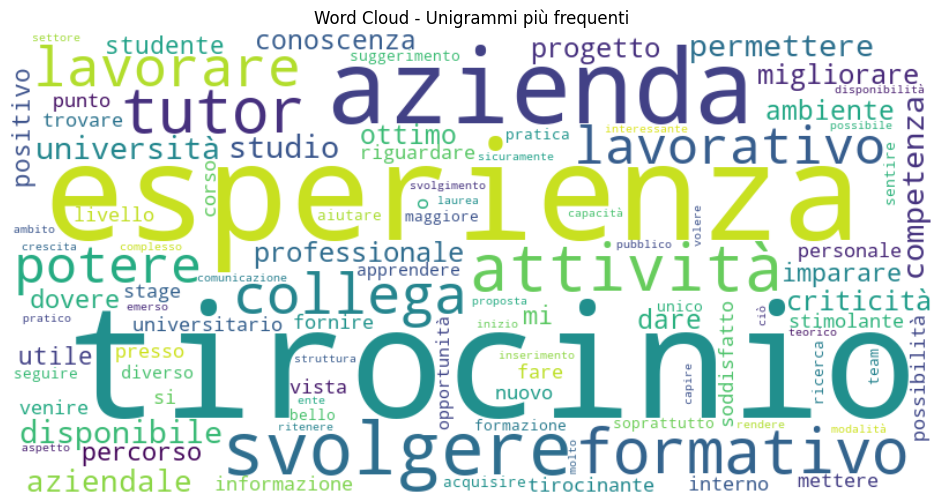

           parola  conteggio
0       tirocinio        314
1      esperienza        231
2         azienda        119
3        svolgere        108
4        attività         89
5           tutor         84
6       formativo         84
7         collega         68
8        lavorare         64
9          potere         62
10     lavorativo         62
11    disponibile         60
12     permettere         60
13         studio         58
14     competenza         57
15     università         57
16      aziendale         52
17  professionale         50
18     migliorare         48
19       progetto         48


In [ ]:
# Genera una WordCloud delle parole più frequenti
from wordcloud import WordCloud

# Crea un dizionario di frequenze
token_freq = Counter(t for txt in df_filtrato['cleaned2'] for t in txt.split())

# Istanzia e genera la word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate_from_frequencies(token_freq)

# Visualizza la WordCloud
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Unigrammi più frequenti')
plt.show()

# Crea una tabella con le frequenze dei token
import pandas as pd
freq_df = pd.DataFrame(token_freq.items(), columns=['parola','conteggio'])
freq_df = freq_df.sort_values('conteggio', ascending=False).reset_index(drop=True)

# Mostra le prime 20 righe della tabella delle frequenze
print(freq_df.head(20))

5b. Bigrammi

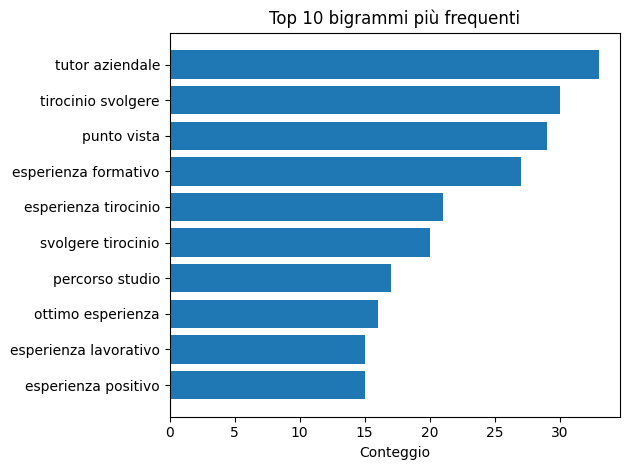

                  bigram  conteggio
0        tutor aziendale         33
1     tirocinio svolgere         30
2            punto vista         29
3   esperienza formativo         27
4   esperienza tirocinio         21
5     svolgere tirocinio         20
6        percorso studio         17
7      ottimo esperienza         16
8  esperienza lavorativo         15
9    esperienza positivo         15


In [ ]:
# Bigrammi: calcolo e visualizzazione
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Calcolo dei top-10 bigrammi
vec2 = CountVectorizer(ngram_range=(2,2), min_df=5)
X2 = vec2.fit_transform(df_filtrato['cleaned2'])
bigrams = sorted(
    zip(vec2.get_feature_names_out(), X2.sum(axis=0).A1),
    key=lambda x: -x[1]
)[:10]

# Creazione DataFrame delle frequenze
bigrams_df = pd.DataFrame(bigrams, columns=['bigram','conteggio'])

# Visualizzazione bar chart orizzontale\ nplt.figure(figsize=(10,6))
plt.barh(bigrams_df['bigram'][::-1], bigrams_df['conteggio'][::-1])
plt.xlabel('Conteggio')
plt.title('Top 10 bigrammi più frequenti')
plt.tight_layout()
plt.show()

# Stampa tabella delle frequenze
print(bigrams_df)

6. Sentiment Analysis

In [ ]:
from transformers import pipeline

# Pipeline Roberta (CPU-only)
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=-1
)

def get_sentiment_roberta(text):
    """Tronca a 512 caratteri e ritorna (label, score)."""
    res = sentiment_pipe(text[:512])[0]
    return res['label'], res['score']

# Applica al DataFrame filtrato
df_filtrato[['sentiment','score']] = df_filtrato['commento'].apply(
    lambda txt: pd.Series(get_sentiment_roberta(txt))
)

# Mostra un estratto
print(df_filtrato[['commento','sentiment','score']].head())


Device set to use cpu


                                            commento sentiment     score
0  a causa del periodo di transizione che stava v...  negative  0.892809
1  A mio avviso, essendo sicuramente una realtà d...   neutral  0.518234
2  A mio parere sarebbe opportuno fornire, almeno...   neutral  0.456108
3  A selezionare più cose avrei messo anche che i...  negative  0.934783
4  According to my opinion, the internship in gen...  negative  0.738524


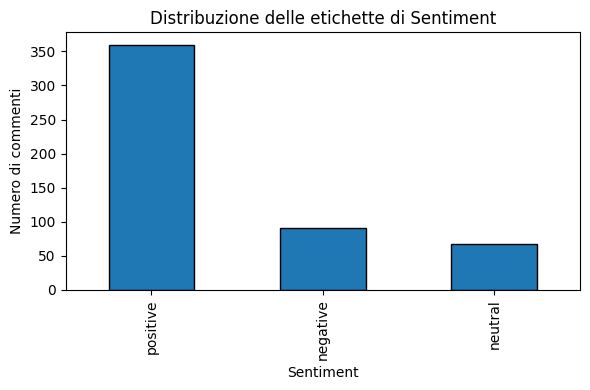

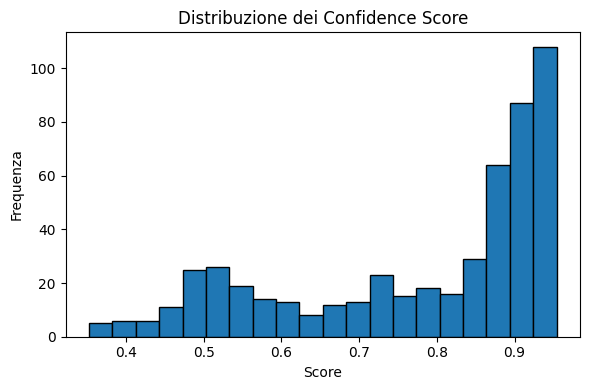

Media dei score per categoria:
 sentiment
negative    0.746929
neutral     0.560405
positive    0.826077
Name: score, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# 1) Bar chart: distribuzione delle etichette di sentiment
sent_counts = df_filtrato['sentiment'].value_counts()
plt.figure(figsize=(6,4))
sent_counts.plot(kind='bar', edgecolor='k')
plt.title('Distribuzione delle etichette di Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Numero di commenti')
plt.tight_layout()
plt.show()

# 2) Istogramma: distribuzione dei confidence score
plt.figure(figsize=(6,4))
plt.hist(df_filtrato['score'], bins=20, edgecolor='k')
plt.title('Distribuzione dei Confidence Score')
plt.xlabel('Score')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

# 3) Media dello score per ogni categoria
avg_scores = df_filtrato.groupby('sentiment')['score'].mean()
print("Media dei score per categoria:\n", avg_scores)


In [ ]:
# Soglia di decisione
TH = 0.7

# 1) Filtra commenti sotto soglia
low_conf = df_filtrato[df_filtrato['score'] < TH]

# 2) Conta assoluto e percentuale sul totale
total = len(df_filtrato)
num_low = len(low_conf)
pct_low = num_low / total * 100
print(f"Commenti con score < {TH}: {num_low} su {total} ({pct_low:.1f} %)")

# 3) Distribuzione per sentiment
dist_low = low_conf['sentiment'].value_counts().rename_axis('sentiment').reset_index(name='count')
dist_low['pct'] = dist_low['count'] / total * 100
print("\nDistribuzione dei casi sotto soglia per sentiment:")
print(dist_low)


Commenti con score < 0.7: 152 su 518 (29.3 %)

Distribuzione dei casi sotto soglia per sentiment:
  sentiment  count        pct
0  positive     68  13.127413
1   neutral     56  10.810811
2  negative     28   5.405405


In [ ]:
# percentuale di low-conf per ciascuna classe rispetto al totale dei commenti di quella classe
total_per_sent = df_filtrato['sentiment'].value_counts()
low_per_sent   = low_conf['sentiment'].value_counts()
pct_internal   = (low_per_sent / total_per_sent * 100).round(1)
print(pct_internal)

# SERVE FINE TUNING


sentiment
negative    30.8
neutral     83.6
positive    18.9
Name: count, dtype: float64


In [ ]:
#sviluppi
#possiamo fare unigrammi e bigrammi per sentiment

In [ ]:
df_filtrato[['commento','sentiment','score']].to_excel('filtered_sentiment.xlsx', index=False)

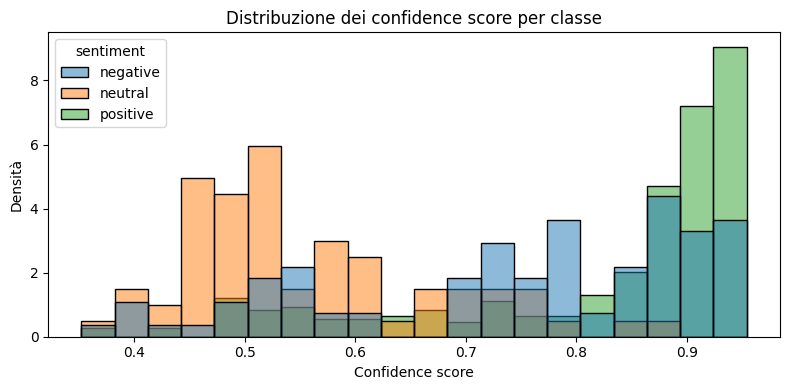

           count      mean       std       min       25%       50%       75%  \
sentiment                                                                      
negative    91.0  0.746929  0.165321  0.360545  0.606372  0.781632  0.877748   
neutral     67.0  0.560405  0.116547  0.352459  0.489023  0.521960  0.617529   
positive   360.0  0.826077  0.145199  0.353066  0.781828  0.892413  0.925969   

                max  
sentiment            
negative   0.950381  
neutral    0.881655  
positive   0.954046  


In [ ]:
# distribuzione cs per classe
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_filtrato,
    x='score',
    hue='sentiment',
    bins=20,
    stat='density',
    common_norm=False
)
plt.title('Distribuzione dei confidence score per classe')
plt.xlabel('Confidence score')
plt.ylabel('Densità')
plt.tight_layout()
plt.show()

# Statistiche descrittive per classe
print(df_filtrato.groupby('sentiment')['score'].describe())
